In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [5]:
df = pd.read_csv("limpia2.csv")

In [ ]:
df.head()

,iddatosgrasas,codigograsa,aceite_base,espesante,grado_nlgi_consistencia,viscosidad_del_aceite_base_a_40degc_cst,penetracion_de_cono_a_25degc_0.1mm,punto_de_gota_degc,estabilidad_mecanica,punto_de_soldadura_cuatro_bolas_kgf,...,factor_de_velocidad,temperatura_de_servicio_degc_min,temperatura_de_servicio_degc_max,categoria,subtitulo,descripcion,beneficios,aplicaciones,color,textura
0,1,grasa_1,semi-sintetico,complejo sulfonato de calcio,2.0,680.0,279,304,1.07,500.0,...,200000.0,5,220,grasa,grasa de servicio pesado para alta resistencia...,el producto es grasa lubricante de servicio pe...,excelentes caracterã­sticas de resistencia al ...,debido a su composiciã³n ã³ptima de aceites de...,cafe,suave
1,2,grasa_2,mineral ht,complejo sulfonato de calcio,1.5,460.0,300,304,2.6,900.0,...,300000.0,-30,150,grasa,grasa para lubricaciã³n de equipo pesado.,el producto es una grasa lubricante de gran ad...,extremo soporte de carga.\r\n@alto contenido d...,lubricaciã³n centralizada de equipo pesado.\r\...,negro,adherente
2,3,grasa_3,mineral ht,complejo sulfonato de calcio,2.0,460.0,265 - 295,300,10,500.0,...,NaN,-10,150,grasa,grasa para lubricaciã³n de equipo pesado.,el producto es una grasa lubricante de gran ad...,extremo soporte de carga.\r\n@alto contenido d...,lubricaciã³n centralizada de equipo pesado.\r\...,negro,adherente
3,4,grasa_4,mineral ht,complejo sulfonato de calcio,2.0,220.0,266 - 295,300,5,500.0,...,NaN,-15,150,grasa,grasa lubricante para condiciones extremas.,el producto es una grasa lubricante elaborada ...,alta estabilidad tã©rmica y anti-oxidante.\r\n...,rodamientos expuestos a alta temperatura y car...,ambar,suave
4,5,grasa_5,mineral ht,complejo de aluminio - poliurea,1.5,680.0,295,260,6.5,620.0,...,NaN,-5,150,grasa,grasa lubricante para servicio pesado con alta...,el producto es un grasa lubricante con propied...,excelente soporte de carga extrema.\r\n@excele...,el producto es ideal para la lubricaciã³n de m...,negro,adherente


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   iddatosgrasas                            51 non-null     int64  
 1   codigograsa                              51 non-null     object 
 2   aceite_base                              47 non-null     object 
 3   espesante                                45 non-null     object 
 4   grado_nlgi_consistencia                  51 non-null     float64
 5   viscosidad_del_aceite_base_a_40degc_cst  50 non-null     float64
 6   penetracion_de_cono_a_25degc_0.1mm       51 non-null     object 
 7   punto_de_gota_degc                       51 non-null     object 
 8   estabilidad_mecanica                     48 non-null     object 
 9   punto_de_soldadura_cuatro_bolas_kgf      50 non-null     float64
 10  desgaste_cuatro_bolas_mm                 27 non-null

In [8]:
import re

# Ejemplo: suponiendo que la columna se llama "punto_de_gota"
col = df['punto_de_gota_degc']

# 1. Extraer los números del texto
col_clean = col.astype(str).apply(lambda x: re.findall(r'\d+\.?\d*', x))

In [9]:
# 2. Convertir listas a valores numéricos (por ejemplo, el primer número encontrado)
col_clean = col_clean.apply(lambda x: float(x[0]) if x else None)
print(col_clean)

0     304.0
1     304.0
2     300.0
3     300.0
4     260.0
5     260.0
6     280.0
7     304.0
8     304.0
9     304.0
10    304.0
11    304.0
12    304.0
13    304.0
14    290.0
15    295.0
16    260.0
17      NaN
18    304.0
19    235.0
20    110.0
21    255.0
22    255.0
23    255.0
24    260.0
25    270.0
26    304.0
27    304.0
28    140.0
29    260.0
30    260.0
31    260.0
32    260.0
33    190.0
34    230.0
35    235.0
36    235.0
37    235.0
38    250.0
39    304.0
40    304.0
41    304.0
42    304.0
43    200.0
44    280.0
45    280.0
46    230.0
47    230.0
48    230.0
49    304.0
50    304.0
Name: punto_de_gota_degc, dtype: float64


In [12]:
# 3. Sustituir en el DataFrame
df['punto_de_gota_num'] = col_clean

# 4. Calcular desviación estándar (ignorando NaN)
std_value = df['punto_de_gota_num'].std()

print(f"Desviación estándar de punto_de_gota: {std_value:.2f}")

Desviación estándar de punto_de_gota: 42.98


In [13]:
mask_mayor = df['punto_de_gota_degc'].astype(str).str.contains(">")
print(mask_mayor)


0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46     True
47     True
48     True
49    False
50    False
Name: punto_de_gota_degc, dtype: bool


In [14]:
std_valor = df['punto_de_gota_num'].std()


In [15]:
df.loc[mask_mayor, 'punto_de_gota_num'] = (
    df.loc[mask_mayor, 'punto_de_gota_num'] + std_valor
)

In [16]:
df.head()

,iddatosgrasas,codigograsa,aceite_base,espesante,grado_nlgi_consistencia,viscosidad_del_aceite_base_a_40degc_cst,penetracion_de_cono_a_25degc_0.1mm,punto_de_gota_degc,estabilidad_mecanica,punto_de_soldadura_cuatro_bolas_kgf,...,temperatura_de_servicio_degc_min,temperatura_de_servicio_degc_max,categoria,subtitulo,descripcion,beneficios,aplicaciones,color,textura,punto_de_gota_num
0,1,grasa_1,semi-sintetico,complejo sulfonato de calcio,2.0,680.0,279,304,1.07,500.0,...,5,220,grasa,grasa de servicio pesado para alta resistencia...,el producto es grasa lubricante de servicio pe...,excelentes caracterã­sticas de resistencia al ...,debido a su composiciã³n ã³ptima de aceites de...,cafe,suave,304.0
1,2,grasa_2,mineral ht,complejo sulfonato de calcio,1.5,460.0,300,304,2.6,900.0,...,-30,150,grasa,grasa para lubricaciã³n de equipo pesado.,el producto es una grasa lubricante de gran ad...,extremo soporte de carga.\r\n@alto contenido d...,lubricaciã³n centralizada de equipo pesado.\r\...,negro,adherente,304.0
2,3,grasa_3,mineral ht,complejo sulfonato de calcio,2.0,460.0,265 - 295,300,10,500.0,...,-10,150,grasa,grasa para lubricaciã³n de equipo pesado.,el producto es una grasa lubricante de gran ad...,extremo soporte de carga.\r\n@alto contenido d...,lubricaciã³n centralizada de equipo pesado.\r\...,negro,adherente,300.0
3,4,grasa_4,mineral ht,complejo sulfonato de calcio,2.0,220.0,266 - 295,300,5,500.0,...,-15,150,grasa,grasa lubricante para condiciones extremas.,el producto es una grasa lubricante elaborada ...,alta estabilidad tã©rmica y anti-oxidante.\r\n...,rodamientos expuestos a alta temperatura y car...,ambar,suave,300.0
4,5,grasa_5,mineral ht,complejo de aluminio - poliurea,1.5,680.0,295,260,6.5,620.0,...,-5,150,grasa,grasa lubricante para servicio pesado con alta...,el producto es un grasa lubricante con propied...,excelente soporte de carga extrema.\r\n@excele...,el producto es ideal para la lubricaciã³n de m...,negro,adherente,260.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   iddatosgrasas                            51 non-null     int64  
 1   codigograsa                              51 non-null     object 
 2   aceite_base                              47 non-null     object 
 3   espesante                                45 non-null     object 
 4   grado_nlgi_consistencia                  51 non-null     float64
 5   viscosidad_del_aceite_base_a_40degc_cst  50 non-null     float64
 6   penetracion_de_cono_a_25degc_0.1mm       51 non-null     object 
 7   punto_de_gota_degc                       51 non-null     object 
 8   estabilidad_mecanica                     48 non-null     object 
 9   punto_de_soldadura_cuatro_bolas_kgf      50 non-null     float64
 10  desgaste_cuatro_bolas_mm                 27 non-null

In [18]:
df = df.drop(columns=['punto_de_gota_degc'])


In [19]:
df.to_csv("limpia3.csv")

In [24]:
from sklearn.linear_model import LinearRegression

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

X = df[['viscosidad_del_aceite_base_a_40degc_cst', 'espesante', 'aceite_base','estabilidad_mecanica']].copy()
y = df['punto_de_gota_num'].copy()

# Convert 'punto_de_gota_degc' to numeric, coercing errors to NaN
#X['punto_de_gota_num'] = pd.to_numeric(X['punto_de_gota_num'], errors='coerce')

# Drop rows with NaN values in the selected columns
X = X.dropna(subset=['viscosidad_del_aceite_base_a_40degc_cst', 'espesante', 'aceite_base','estabilidad_mecanica'])
y = y[X.index] # Ensure y corresponds to the filtered X

X = pd.get_dummies(X, drop_first=True)


modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

print("\nCoeficientes del modelo:")
for nombre, coef in zip(X.columns, modelo.coef_):
    print(f"  {nombre}: {coef:.4f}")

print("\nIntercepto:", round(modelo.intercept_, 4))
print("R² (bondad de ajuste):", round(r2_score(y, y_pred), 4))
print("RMSE (error promedio):", round(np.sqrt(mean_squared_error(y, y_pred)), 4))


Coeficientes del modelo:
  viscosidad_del_aceite_base_a_40degc_cst: -0.0600
  espesante_complejo de aluminio: -23.7660
  espesante_complejo de aluminio - poliurea: -19.7896
  espesante_complejo de litio: -12.1872
  espesante_complejo de poliurea: -73.2517
  espesante_complejo sulfonato de calcio: -6.7718
  aceite_base_mineral hc: -12.1872
  aceite_base_mineral ht: 2.3974
  aceite_base_mineral refinado: 10.2789
  aceite_base_mineral usp: -17.5484
  aceite_base_semi-sintetico: 79.6256
  estabilidad_mecanica_1: 70.3094
  estabilidad_mecanica_1.07: -56.1408
  estabilidad_mecanica_1.4: 6.2177
  estabilidad_mecanica_1.5: 28.2907
  estabilidad_mecanica_1.6: 27.6481
  estabilidad_mecanica_10: 3.8815
  estabilidad_mecanica_11: -37.6503
  estabilidad_mecanica_2.6: 18.0861
  estabilidad_mecanica_3.2: -25.7881
  estabilidad_mecanica_3.8: 28.2907
  estabilidad_mecanica_4: 2.0221
  estabilidad_mecanica_4.4: 70.3094
  estabilidad_mecanica_5: -10.5249
  estabilidad_mecanica_5.2: -9.8948
  estabilidad

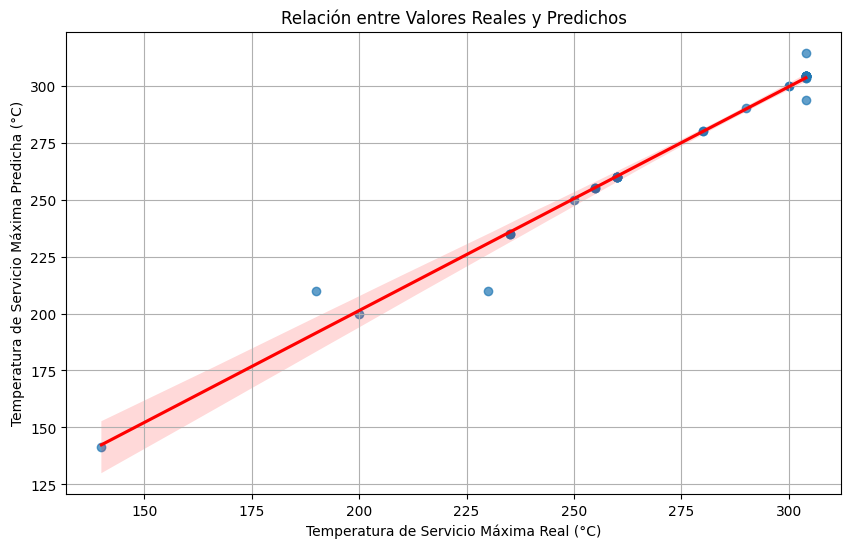

In [28]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
plt.xlabel("Temperatura de Servicio Máxima Real (°C)")
plt.ylabel("Temperatura de Servicio Máxima Predicha (°C)")
plt.title("Relación entre Valores Reales y Predichos")
plt.grid(True)
plt.show()